# BLOQUE 1: Principios de Diseño de Pipelines Reproducibles (20 min)
#https://datos.salud.gob.ar/dataset/tasa-de-natalidad/archivo/0f68d5c6-e667-40ca-90fd-4784336e092e

Teoría y Escenario Real

El problema en el mundo real: En producción, los datos cambian constantemente (ej. todos los años el DEIS publica un nuevo renglón de natalidad). Si procesamos los datos con celdas de Jupyter sueltas o de forma manual, el código se rompe, toma tiempo rehacerlo y es propenso a errores humanos.

La solución: Un Pipeline Reproducible. Es un conjunto de funciones modulares que automatizan la ingesta, limpieza y transformación. Entra un archivo crudo (raw data) y sale un objeto listo para el modelo de Machine Learning, sin intervención manual.

Particularidad de nuestro Dataset: El archivo tiene los años en las filas y las provincias en las columnas. Para aplicar algoritmos de Machine Learning en scikit-learn, las filas deben ser las instancias (las provincias a segmentar) y las columnas deben ser las características (features, es decir, los años). Por lo tanto, el pipeline debe transponer (.T) la matriz y escalar los datos, ya que los modelos basados en distancias son sensibles a las magnitudes.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# =====================================================================
# SECCIÓN 1: El Pipeline de Ingesta y Transformación
# =====================================================================

def pipeline_preprocesamiento(path_archivo):
    """Pipeline reproducible para limpiar y transformar el dataset de natalidad."""
    # 1. Carga de datos crudos
    df = pd.read_csv(path_archivo)

    # 2. Convertir el índice de tiempo a año y setearlo
    df['indice_tiempo'] = pd.to_datetime(df['indice_tiempo']).dt.year
    df.set_index('indice_tiempo', inplace=True)

    # 3. Transposición Crucial: Filas = Provincias (Instancias), Columnas = Años (Features)
    df_provincias = df.T

    # 4. Tratamiento de nulos por imputación matemática (Media por provincia)
    df_provincias = df_provincias.fillna(df_provincias.mean())

    # 5. Escalado de datos para algoritmos de distancia
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_provincias)

    return df_provincias, X_scaled

# Ejecución en vivo:
df_provincias, X = pipeline_preprocesamiento('tasa-natalidad-deis-2000-2024.csv')
print(f"Instancias a segmentar: {df_provincias.shape[0]} provincias.")
print(f"Cantidad de features por provincia: {df_provincias.shape[1]} años analizados.")

Instancias a segmentar: 25 provincias.
Cantidad de features por provincia: 25 años analizados.


# BLOQUE 2: Teoría Práctica: Supervisado vs. No Supervisado (20 min)

1 Teoría y Escenario Real
Supervisado vs. No Supervisado: * Si quisiéramos predecir el número exacto de nacimientos en Formosa para 2026, sería Supervisado (Regresión) porque tenemos una etiqueta histórica que guíe al modelo.

En nuestro caso real, el Ministerio de Salud no sabe cuántos o cuáles son los perfiles demográficos del país. No hay etiquetas de "Provincia con natalidad decreciente" o "Provincia con natalidad estable". Buscamos que el algoritmo encuentre esos patrones ocultos por sí solo. Esto es Aprendizaje No Supervisado.

Caso de Estudio (Segmentación): Usaremos el algoritmo K-Means. Este algoritmo agrupa las provincias asignando centros geométricos (centroides) e iterando hasta que cada provincia quede asociada al centroide más cercano por distancia euclidiana.

In [7]:
# =====================================================================
# SECCIÓN 2: Aplicación de K-Means (Prueba inicial con K=3)
# =====================================================================

# Inicializamos el modelo con un estado aleatorio fijo para reproducibilidad
kmeans_prueba = KMeans(n_clusters=3, random_state=42, n_init=10)

# Entrenamos y predecimos en un solo paso
clusters_prueba = kmeans_prueba.fit_predict(X)

# Asignamos temporalmente para visualizar qué provincias se agrupan
df_provincias['cluster_inicial'] = clusters_prueba
print("Muestra de provincias y su asignación inicial de grupo:")
print(df_provincias['cluster_inicial'].head(10))

Muestra de provincias y su asignación inicial de grupo:
natalidad_argentina                          1
natalidad_ciudad_autonoma_de_buenos_aires    2
natalidad_buenos_aires                       1
natalidad_catamarca                          1
natalidad_cordoba                            2
natalidad_corrientes                         0
natalidad_chaco                              0
natalidad_chubut                             1
natalidad_entre_rios                         1
natalidad_formosa                            0
Name: cluster_inicial, dtype: int32


# BLOQUE 3: Métricas y Estrategias de Validación (20 min)

1. Teoría y Escenario Real
El dilema del analista: En el bloque anterior elegimos 3 grupos porque quisimos. Pero, ¿cómo demostramos matemáticamente ante las autoridades que 3 es mejor que 2 o 5? En No Supervisado no hay métricas tradicionales como el Accuracy.

Estrategias de Validación:

Método del Codo (Inercia): Mide la suma de las distancias al cuadrado de cada punto a su centroide. A más clusters, menor inercia, pero buscamos el punto de inflexión ("el codo") donde agregar más clusters ya no reduzca significativamente la inercia.

Coeficiente de Silueta: Mide qué tan cerca está un punto de su propio cluster en comparación con los otros clusters. Va de -1 a 1. Un valor alto significa que los grupos están bien definidos y aislados.

Evaluación del Coeficiente de Silueta por cada K:
Para K = 2 -> Silhouette Score: 0.3969
Para K = 3 -> Silhouette Score: 0.3461
Para K = 4 -> Silhouette Score: 0.3523
Para K = 5 -> Silhouette Score: 0.3023
Para K = 6 -> Silhouette Score: 0.2976


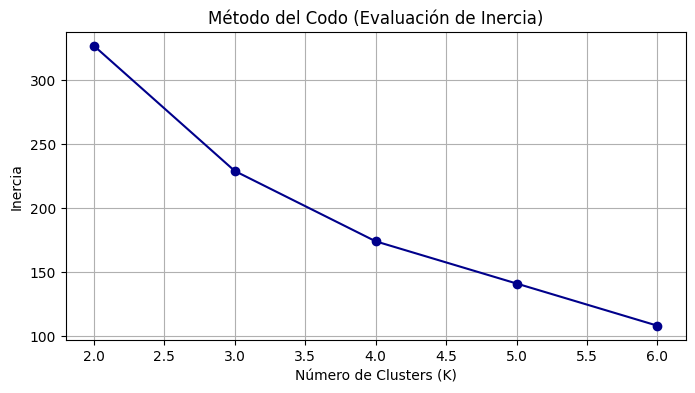

In [6]:
# =====================================================================
# SECCIÓN 3: Evaluación de Métricas de Validación
# =====================================================================

inercias = []
siluetas = []
rango_k = range(2, 7)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X, labels))

# 1. Imprimir los scores de Silueta
print("Evaluación del Coeficiente de Silueta por cada K:")
for k, score in zip(rango_k, siluetas):
    print(f"Para K = {k} -> Silhouette Score: {score:.4f}")

# 2. Graficar el Método del Codo para los alumnos
plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercias, marker='o', color='darkblue')
plt.title('Método del Codo (Evaluación de Inercia)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

# BLOQUE 4: Casos de Estudio y "Recomendaciones" (15 min)

1. Teoría y Escenario Real (5 min)
De los datos a la acción (Analytics to Action): Un cluster por sí solo no genera valor. El data scientist debe interpretar qué significa cada grupo.

Lógica de recomendación: Al entender el perfil demográfico de cada cluster (ej: provincias con natalidad en caída libre vs estables), el pipeline puede disparar de forma automática recomendaciones de políticas públicas o asignación presupuestaria automatizada para cada provincia del mapa.

In [8]:
# =====================================================================
# SECCIÓN 4: Modelo Definitivo e Inferencia de Políticas
# =====================================================================

# Asumiendo que el análisis arrojó un K óptimo (ej. K=3)
k_final = 3
modelo_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_provincias['cluster_final'] = modelo_final.fit_predict(X)

# Analizamos el promedio de los años extremos para interpretar el comportamiento
perfil_clusters = df_provincias.groupby('cluster_final')[[2000, 2012, 2024]].mean()
print("\nComportamiento histórico promedio por grupo:")
print(perfil_clusters)

# Creamos una lógica automatizada de Recomendación
def sistema_recomendacion_politica(cluster_id):
    if cluster_id == 0:
        return "Alerta Demográfica: Reorientar presupuesto a salud de adultos mayores."
    elif cluster_id == 1:
        return "Prioridad Alta: Planificar construcción de nuevos jardines y escuelas primarias."
    else:
        return "Estable: Mantener subsidios existentes y monitorear tasas de control prenatal."

# Aplicamos la recomendación al dataset original
df_provincias['Accion_Recomendada'] = df_provincias['cluster_final'].apply(sistema_recomendacion_politica)

print("\nVista final del entregable para el Ministerio (Muestra):")
print(df_provincias[['cluster_final', 'Accion_Recomendada']].head(10))


Comportamiento histórico promedio por grupo:
indice_tiempo       2000       2012       2024
cluster_final                                 
0              24.042857  19.971429  10.885714
1              20.614286  18.407143   8.564286
2              16.625000  15.600000   8.200000

Vista final del entregable para el Ministerio (Muestra):
indice_tiempo                              cluster_final  \
natalidad_argentina                                    1   
natalidad_ciudad_autonoma_de_buenos_aires              2   
natalidad_buenos_aires                                 1   
natalidad_catamarca                                    1   
natalidad_cordoba                                      2   
natalidad_corrientes                                   0   
natalidad_chaco                                        0   
natalidad_chubut                                       1   
natalidad_entre_rios                                   1   
natalidad_formosa                                      0   

